##### Full dataset classification (26 classes)

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [4]:
dataset = pd.read_csv('../Machine learning & classification/full_csv_dataset - 26classes.csv')
dataset.head()

,ip_source,ip_dest,ts,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,192.168.1.100,192.168.1.1,1780569475,1199.950214,46503.9,8.1,99.0,2.801070,2.801070,0.0,...,43.993163,90.6,4.013128e-02,5.5,12.612735,62.215727,2707.487462,0.9,38.5,SqlInjection
1,192.168.1.100,192.168.1.1,1780569475,60.404083,622.0,7.6,79.1,43.511480,43.511480,0.0,...,51.110890,104.9,1.298180e-02,5.5,12.610703,72.281714,5972.854396,0.9,38.5,SqlInjection
2,192.168.1.101,192.168.1.1,1780569475,1.908170,33372.2,6.0,59.2,22.794516,22.794516,0.0,...,172.033472,1065.6,2.803397e-03,5.5,52.860757,243.292070,100371.594600,0.3,38.5,SqlInjection
3,192.168.1.102,192.168.1.1,1780569475,24.582628,117027.4,6.0,59.2,43.750276,43.750276,0.0,...,654.612795,1595.4,1.114039e-02,5.5,43.530928,925.762293,499958.296100,0.9,38.5,SqlInjection
4,192.168.1.103,192.168.1.1,1780569475,289.396717,5306.9,8.7,100.8,17.791105,17.791105,0.0,...,60.920252,140.6,1.664818e+08,13.5,15.075410,86.215931,3815.088877,1.0,244.6,SqlInjection


In [13]:
#Unique values in the Label target column
dataset['label'].unique()

<StringArray>
[           'SqlInjection',        'CommandInjection',
          'Recon-PortScan',            'Recon-OSScan',
    'Recon-Host-Discovery',           'DOS_udp_flood',
           'DOS_tcp_flood',           'DOS_syn_flood',
                'DOS_LAND',          'DOS_HTTP_flood',
  'DDOS_UDP_FRAGMENTATION',          'DDOS_UDP_flood',
          'DDOS_TCP_flood',          'DDOS_SYN_FLOOD',
          'DDOS_RST_FLOOD',      'DDOS_RST_FIN_flood',
      'DDOS_PSH_ACK_FLOOD',      'DDOS_PING_OF_DEATH',
       'DDOS_RAW_IP_FLOOD', 'DDOS_ICMP_FARGMENTATION',
         'DDOS_ICMP_flood',         'DDOS_HTTP_FLOOD',
          'DDOS_FIN_FLOOD',      'DDOS_ACK_SYN_FLOOD',
  'DDOS_ACK_FRAGMENTATION',          'DDOS_ack_flood',
           'BenignTraffic']
Length: 27, dtype: str

In [14]:
#remove null values from the dataset
dataset = dataset.dropna()
dataset.info()

<class 'pandas.DataFrame'>
Index: 39768 entries, 0 to 39777
Data columns (total 50 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ip_source        39768 non-null  str    
 1   ip_dest          39768 non-null  str    
 2   ts               39768 non-null  int64  
 3   flow_duration    39768 non-null  float64
 4   Header_Length    39768 non-null  float64
 5   Protocol Type    39768 non-null  float64
 6   Duration         39768 non-null  float64
 7   Rate             39768 non-null  float64
 8   Srate            39768 non-null  float64
 9   Drate            39768 non-null  float64
 10  fin_flag_number  39768 non-null  int64  
 11  syn_flag_number  39768 non-null  int64  
 12  rst_flag_number  39768 non-null  int64  
 13  psh_flag_number  39768 non-null  int64  
 14  ack_flag_number  39768 non-null  int64  
 15  ece_flag_number  39768 non-null  int64  
 16  cwr_flag_number  39768 non-null  int64  
 17  ack_count        39768 non-n

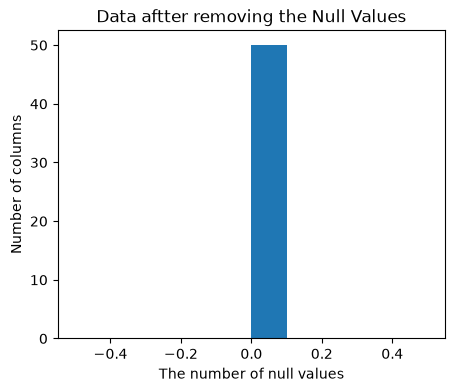

In [8]:
#Checking the null values in the dataset again.
plt.figure(1,figsize=( 5,4))
plt.hist( dataset.isna().sum())
plt.title('Data aftter removing the Null Values')
plt.xlabel('The number of null values')
plt.ylabel('Number of columns')
plt.show()

In [10]:
label_mapping = {
    'BenignTraffic': 0,
    'SqlInjection': 1,
    'CommandInjection': 2,
    'Recon-PortScan': 3,
    'Recon-OSScan': 4,
    'Recon-Host-Discovery': 5,
    'DOS_udp_flood': 6,
    'DOS_tcp_flood': 7,
    'DOS_syn_flood': 8,
    'DOS_LAND': 9,
    'DOS_HTTP_flood': 10,
    'DDOS_UDP_FRAGMENTATION': 11,
    'DDOS_UDP_flood': 12,
    'DDOS_TCP_flood': 13,
    'DDOS_SYN_FLOOD': 14,
    'DDOS_RST_FLOOD': 15,
    'DDOS_RST_FIN_flood': 16,
    'DDOS_PSH_ACK_FLOOD': 17,
    'DDOS_PING_OF_DEATH': 18,
    'DDOS_RAW_IP_FLOOD': 19,
    'DDOS_ICMP_FARGMENTATION': 20,
    'DDOS_ICMP_flood': 21,
    'DDOS_HTTP_FLOOD': 22,
    'DDOS_FIN_FLOOD': 23,
    'DDOS_ACK_SYN_FLOOD': 24,
    'DDOS_ACK_FRAGMENTATION': 25,
    'DDOS_ack_flood': 26
}

dataset['label'] = dataset['label'].map(label_mapping)

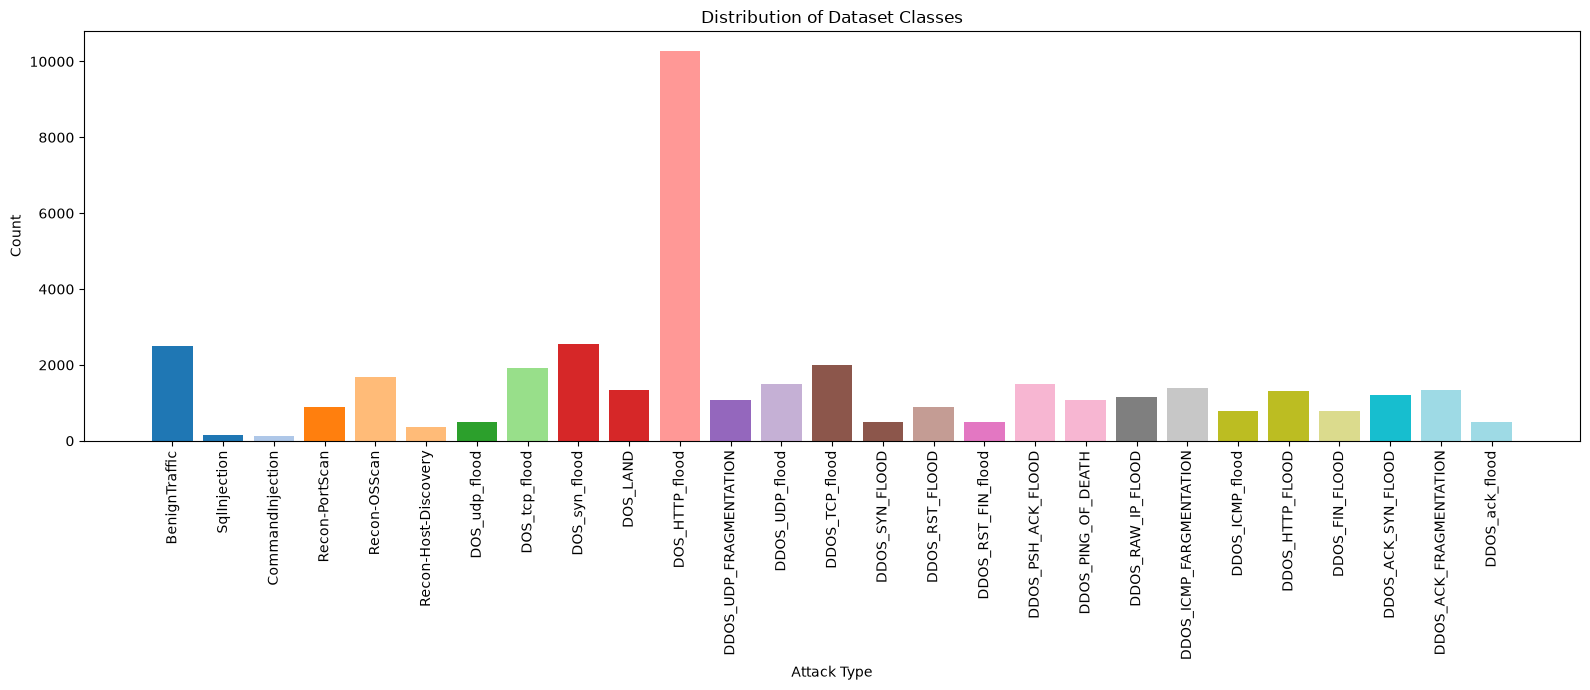

In [12]:
reverse_mapping = {v: k for k, v in label_mapping.items()}
class_counts = dataset['label'].value_counts().sort_index()
colors = plt.cm.tab20(np.linspace(0, 1, len(class_counts)))
plt.figure(figsize=(16, 7))
plt.bar(
    [reverse_mapping[i] for i in class_counts.index],
    class_counts.values,
    color=colors
)
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.title("Distribution of Dataset Classes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [13]:
#statistical info
pd.set_option('display.float_format', lambda x: '%.3f' % x) 
dataset.describe()

,ts,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
count,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,...,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000,39768.000
mean,1780676745.515,64.331,73096.109,10.694,52.806,353117.637,353115.486,2.150,0.357,0.447,...,144.232,24795.020,11938312.186,56.359,16.599,161.808,49060.933,18131.083,75.253,12.088
std,68066.432,581.747,422593.587,27.564,104.089,18759693.025,18759693.065,6.638,0.479,0.497,...,212.064,109636.647,42959899.547,156.260,8.890,293.993,404155.562,32839.430,162.183,6.684
min,1780566162.000,0.000,0.000,0.000,0.000,0.004,0.000,0.000,0.000,0.000,...,0.000,53.200,0.000,1.000,0.000,0.000,-326639.154,0.000,1.000,0.000
25%,1780638530.750,0.425,20.000,6.000,0.484,19.172,18.746,0.000,0.000,0.000,...,36.787,1528.450,0.015,12.000,11.141,35.630,-4655.938,605.896,14.000,8.000
50%,1780685425.500,0.986,20.000,6.000,1.091,29.340,25.886,0.000,0.000,0.000,...,103.627,3226.000,0.038,21.000,12.807,105.046,-641.703,7167.760,26.000,10.000
75%,1780732926.000,10.185,20.000,6.000,64.000,61.300,58.279,0.000,1.000,1.000,...,140.857,7300.000,0.059,34.000,19.835,144.359,27.294,15723.143,45.000,17.000
max,1780813496.000,51182.927,8268053.000,254.000,529.603,1000000000.000,1000000000.000,46.968,1.000,1.000,...,4025.258,1001653.000,167638871.500,2767.000,93.142,5703.475,16363918.440,477103.090,2767.000,26.000


In [15]:
#drop unuseful columns
columns_to_drop = ['ip_source', 'ip_dest','ts','Protocol Type']
dataset = dataset.drop(columns=columns_to_drop, errors='ignore')
print(dataset.columns.tolist())
print("Number of columns:", dataset.shape[1])

['flow_duration', 'Header_Length', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']
Number of columns: 46


In [17]:
# Remove duplicates
dataset = dataset.drop_duplicates()

In [18]:
# Handle infinities
dataset.replace([np.inf, -np.inf], np.nan, inplace=True)

,flow_duration,Header_Length,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,1199.950,46503.900,99.000,2.801,2.801,0.000,0,0,0,0,...,43.993,90.600,0.040,5.500,12.613,62.216,2707.487,0.900,38.500,1
1,60.404,622.000,79.100,43.511,43.511,0.000,0,0,0,0,...,51.111,104.900,0.013,5.500,12.611,72.282,5972.854,0.900,38.500,1
2,1.908,33372.200,59.200,22.795,22.795,0.000,0,0,0,0,...,172.033,1065.600,0.003,5.500,52.861,243.292,100371.595,0.300,38.500,1
3,24.583,117027.400,59.200,43.750,43.750,0.000,0,0,0,0,...,654.613,1595.400,0.011,5.500,43.531,925.762,499958.296,0.900,38.500,1
4,289.397,5306.900,100.800,17.791,17.791,0.000,0,0,0,0,...,60.920,140.600,166481815.300,13.500,15.075,86.216,3815.089,1.000,244.600,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39773,32.252,19431.800,123.500,9.610,9.610,0.000,0,0,0,0,...,50.094,86.200,0.025,5.500,13.968,70.844,2928.715,0.900,38.500,0
39774,17.349,10668.500,83.500,7.086,7.086,0.000,0,0,0,0,...,51.815,105.300,166520412.600,13.500,13.510,73.406,2733.864,1.000,244.600,0
39775,34.278,64873.000,107.800,21.263,21.263,0.000,0,0,0,0,...,181.975,184.400,0.013,5.500,18.286,257.352,48797.275,0.900,38.500,0
39776,20.382,1857610.800,214.300,80.195,80.195,0.000,0,0,0,0,...,857.704,210.800,166523287.500,13.500,37.623,1212.186,735774.095,1.000,244.600,0


In [ ]:
# Remove missing values
dataset = dataset.dropna()

In [33]:
#modeling 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
#label - features
X = dataset.drop(columns=["label"])
y = dataset["label"]

In [34]:
# XGBoost needs numeric labels
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [35]:
#split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.30, stratify=y_enc, random_state=42
)

In [36]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)),
    ]),
    "Random Forest":      RandomForestClassifier(n_jobs=-1, random_state=42),
    "Decision Tree":      DecisionTreeClassifier(random_state=42),
    "Gradient Boosting":  HistGradientBoostingClassifier(random_state=42),   # <-- fast replacement
    "XGBoost":            XGBClassifier(
                              n_jobs=-1, random_state=42,
                              eval_metric="mlogloss", tree_method="hist"
                          ),
    "LightGBM":           LGBMClassifier(
                              n_jobs=-1, random_state=42,
                              num_leaves=63,
                              min_data_in_leaf=5,     # default 20 was killing rare classes
                              min_split_gain=0.0,
                              n_estimators=200,
                              verbose=-1,             # silence the wall of warnings
                          ),
    "Neural Network":     Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            max_iter=200,
            random_state=42,
        )),
    ]),
}

In [37]:
#evaluation matrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
    })


=== Logistic Regression ===
Accuracy : 0.9165
Precision: 0.9077
Recall   : 0.9165
F1-score : 0.9072

=== Random Forest ===
Accuracy : 0.9493
Precision: 0.9488
Recall   : 0.9493
F1-score : 0.9475

=== Decision Tree ===
Accuracy : 0.9446
Precision: 0.9444
Recall   : 0.9446
F1-score : 0.9443

=== Gradient Boosting ===
Accuracy : 0.9337
Precision: 0.9382
Recall   : 0.9337
F1-score : 0.9354

=== XGBoost ===
Accuracy : 0.9482
Precision: 0.9470
Recall   : 0.9482
F1-score : 0.9473

=== LightGBM ===
Accuracy : 0.3647
Precision: 0.3945
Recall   : 0.3647
F1-score : 0.3479

=== Neural Network ===
Accuracy : 0.9238
Precision: 0.9216
Recall   : 0.9238
F1-score : 0.9215


In [39]:
# Summary table
results_df = pd.DataFrame(results).sort_values("F1-score", ascending=False)
print("\n=== Summary table ===")
print(results_df.to_string(index=False))


=== Summary table ===
              Model  Accuracy  Precision  Recall  F1-score
      Random Forest     0.949      0.949   0.949     0.947
            XGBoost     0.948      0.947   0.948     0.947
      Decision Tree     0.945      0.944   0.945     0.944
  Gradient Boosting     0.934      0.938   0.934     0.935
     Neural Network     0.924      0.922   0.924     0.921
Logistic Regression     0.917      0.908   0.917     0.907
           LightGBM     0.365      0.395   0.365     0.348
